# Uncertainty-Aware Protein Stability Prediction (v3)
## Decoupled training + robust likelihoods

**Problem identified in v2:** Sigma was being used to mask mean prediction errors. The NLL loss allows the model to inflate sigma instead of improving mu.

**Fixes applied in this version:**
1. **Two-stage training**: train mu first (MSE), then freeze mu and train sigma (NLL)
2. **Sigma regularization**: penalize deviation from a prior sigma
3. **Student-t likelihood**: heavier tails, more robust to outlier ddG values

We compare 5 model variants to find the best approach.

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

sys.path.insert(0, '.')
from uapp.data import load_cached_embeddings, make_loader
from uapp.heads import build_head, is_probabilistic
from uapp.train import TrainConfig, train_head, train_head_two_stage
from uapp.evaluate import (
    evaluate_head, compute_coverage_curve,
    gather_probabilistic_predictions,
)
from uapp.utils import set_seed

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.15,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12, 'figure.dpi': 120,
})
DEVICE = torch.device('cpu')
SEED = 42
set_seed(SEED)
print(f'torch {torch.__version__} | device: {DEVICE}')

torch 2.11.0 | device: cpu


---
## 1. Load data

In [2]:
CACHE = Path('cache/t2837_embeddings_v2.pt')
assert CACHE.exists(), 'Run 01_cache_embeddings_esm_v2.py first'
splits, meta = load_cached_embeddings(CACHE)
for s in ('train','val','test'):
    X, y = splits[s]
    print(f'{s:>5s}: {X.shape[0]} mut | dim={X.shape[1]} | ddG=[{y.min():.1f}, {y.max():.1f}]')

X_tr, y_tr = splits['train']
X_va, y_va = splits['val']
X_te, y_te = splits['test']
d_in = X_tr.shape[-1]
train_loader = make_loader(X_tr, y_tr, 128, shuffle=True)
val_loader = make_loader(X_va, y_va, 128, shuffle=False)
test_loader = make_loader(X_te, y_te, 256, shuffle=False)

# Target std for sigma prior
y_std = float(y_tr.std())
print(f'\nTarget std (train): {y_std:.3f} — using as sigma_prior')

train: 1395 mut | dim=680 | ddG=[-13.7, 8.7]
  val: 1019 mut | dim=680 | ddG=[-5.1, 12.2]
 test: 170 mut | dim=680 | ddG=[-2.9, 8.9]

Target std (train): 1.787 — using as sigma_prior


---
## 2. Define experiments

We compare 5 variants:

| # | Name | Loss | Training | Sigma constraint |
|---|------|------|----------|------------------|
| 1 | MSE baseline | MSE | Standard | None (no sigma) |
| 2 | Gaussian NLL | Gaussian NLL | Standard | None |
| 3 | Two-stage | Gaussian NLL | Stage1: MSE, Stage2: NLL (mu frozen) | None |
| 4 | Regularized NLL | Gaussian NLL + sigma penalty | Standard | Prior + lambda |
| 5 | Student-t NLL | Student-t (nu=3) | Standard | None |

In [3]:
EXPERIMENTS = {}
HEAD_KWARGS = {'d_hidden': 256, 'dropout': 0.1, 'init_sigma_bias': 0.5}

COLORS = {
    'mse': '#64748B',
    'gaussian_nll': '#0D7377',
    'two_stage': '#2E7D32',
    'regularized': '#7B4FB0',
    'student_t': '#E8913A',
}
LABELS = {
    'mse': 'MSE baseline',
    'gaussian_nll': 'Gaussian NLL',
    'two_stage': 'Two-stage',
    'regularized': 'Regularized NLL',
    'student_t': 'Student-t (nu=3)',
}

In [4]:
# ── Experiment 1: MSE baseline ──
print('='*55, '\n  MSE baseline\n', '='*55)
set_seed(SEED)
head_mse = build_head('mse', d_in, d_hidden=256, dropout=0.1)
cfg_mse = TrainConfig(max_epochs=300, lr=1e-3, patience=30, log_every=50)
head_mse, hist_mse = train_head(head_mse, train_loader, val_loader, cfg_mse, DEVICE)
EXPERIMENTS['mse'] = {'head': head_mse, 'history': [hist_mse]}
print(f'  Best val: {hist_mse.best_val_loss:.4f} @ ep {hist_mse.best_epoch}')

  MSE baseline
  Best val: 3.7312 @ ep 19


In [5]:
# ── Experiment 2: Standard Gaussian NLL ──
print('='*55, '\n  Gaussian NLL (standard)\n', '='*55)
set_seed(SEED)
head_gnll = build_head('two_head_nll', d_in, **HEAD_KWARGS)
cfg_gnll = TrainConfig(max_epochs=300, lr=1e-3, patience=30, log_every=50, loss_type='gaussian')
head_gnll, hist_gnll = train_head(head_gnll, train_loader, val_loader, cfg_gnll, DEVICE)
EXPERIMENTS['gaussian_nll'] = {'head': head_gnll, 'history': [hist_gnll]}
print(f'  Best val: {hist_gnll.best_val_loss:.4f} @ ep {hist_gnll.best_epoch}')

  Gaussian NLL (standard)
  Best val: 1.1505 @ ep 1


In [6]:
# ── Experiment 3: Two-stage training ──
print('='*55, '\n  Two-stage (MSE then NLL)\n', '='*55)
set_seed(SEED)
head_2s = build_head('two_head_nll', d_in, **HEAD_KWARGS)
cfg_s1 = TrainConfig(max_epochs=200, lr=1e-3, patience=25, log_every=50)
cfg_s2 = TrainConfig(max_epochs=200, lr=5e-4, patience=25, log_every=50, loss_type='gaussian')
head_2s, hist_2s_1, hist_2s_2 = train_head_two_stage(
    head_2s, train_loader, val_loader, cfg_s1, cfg_s2, DEVICE
)
EXPERIMENTS['two_stage'] = {'head': head_2s, 'history': [hist_2s_1, hist_2s_2]}
print(f'  Stage 1 best: {hist_2s_1.best_val_loss:.4f} @ ep {hist_2s_1.best_epoch}')
print(f'  Stage 2 best: {hist_2s_2.best_val_loss:.4f} @ ep {hist_2s_2.best_epoch}')

  Two-stage (MSE then NLL)
  Stage 1 best: 1.2276 @ ep 3
  Stage 2 best: 1.1942 @ ep 3


In [7]:
# ── Experiment 4: Regularized NLL ──
print('='*55, '\n  Regularized NLL\n', '='*55)
set_seed(SEED)
head_reg = build_head('two_head_nll', d_in, **HEAD_KWARGS)
cfg_reg = TrainConfig(
    max_epochs=300, lr=1e-3, patience=30, log_every=50,
    loss_type='regularized', sigma_prior=y_std, lambda_reg=0.1,
)
head_reg, hist_reg = train_head(head_reg, train_loader, val_loader, cfg_reg, DEVICE)
EXPERIMENTS['regularized'] = {'head': head_reg, 'history': [hist_reg]}
print(f'  Best val: {hist_reg.best_val_loss:.4f} @ ep {hist_reg.best_epoch}')

  Regularized NLL
  Best val: 1.1587 @ ep 1


In [8]:
# ── Experiment 5: Student-t NLL ──
print('='*55, '\n  Student-t NLL (nu=3)\n', '='*55)
set_seed(SEED)
head_st = build_head('two_head_nll', d_in, **HEAD_KWARGS)
cfg_st = TrainConfig(
    max_epochs=300, lr=1e-3, patience=30, log_every=50,
    loss_type='student_t', student_t_nu=3.0,
)
head_st, hist_st = train_head(head_st, train_loader, val_loader, cfg_st, DEVICE)
EXPERIMENTS['student_t'] = {'head': head_st, 'history': [hist_st]}
print(f'  Best val: {hist_st.best_val_loss:.4f} @ ep {hist_st.best_epoch}')

  Student-t NLL (nu=3)
  Best val: 2.0135 @ ep 4


---
## 3. Evaluate all variants

In [9]:
results = {}
prob_preds = {}

for name, exp in EXPERIMENTS.items():
    head = exp['head']
    results[name] = evaluate_head(head, test_loader, DEVICE, name)
    if is_probabilistic(head):
        mu, sigma, y = gather_probabilistic_predictions(head, test_loader, DEVICE)
        prob_preds[name] = (mu, sigma, y)

# Build comparison table
rows = []
for name in EXPERIMENTS:
    r = results[name]
    row = {'Variant': LABELS[name], 'RMSE': f'{r.rmse:.4f}', 'MAE': f'{r.mae:.4f}'}
    if r.nll is not None:
        row['NLL'] = f'{r.nll:.4f}'
        row['ICE'] = f'{r.ice:.4f}'
        row['90% cov'] = f'{r.coverage["0.90"]:.1%}'
        # Compute Pearson
        mu_arr = prob_preds[name][0]
        y_arr = prob_preds[name][2]
        rp, _ = pearsonr(y_arr, mu_arr)
        row['Pearson r'] = f'{rp:.4f}'
        # Sigma stats
        sig = prob_preds[name][1]
        row['sigma_mean'] = f'{sig.mean():.3f}'
        row['sigma_std'] = f'{sig.std():.3f}'
    else:
        row.update({'NLL': '\u2014', 'ICE': '\u2014', '90% cov': '\u2014',
                    'Pearson r': '\u2014', 'sigma_mean': '\u2014', 'sigma_std': '\u2014'})
        mu_arr = results[name]
    rows.append(row)

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

         Variant   RMSE    MAE    NLL    ICE 90% cov Pearson r sigma_mean sigma_std
    MSE baseline 1.6055 1.0925      —      —       —         —          —         —
    Gaussian NLL 1.5929 1.2536 1.9488 0.0865   95.9%    0.4006      2.024     0.139
       Two-stage 1.4455 1.0222 1.8181 0.0829   92.9%    0.4830      1.540     0.119
 Regularized NLL 1.5949 1.2562 1.9505 0.0876   95.9%    0.3999      2.028     0.135
Student-t (nu=3) 1.3978 0.9483 1.9010 0.0258   86.5%    0.5065      1.025     0.329


---
## 4. Predicted vs. actual ddG (all variants)

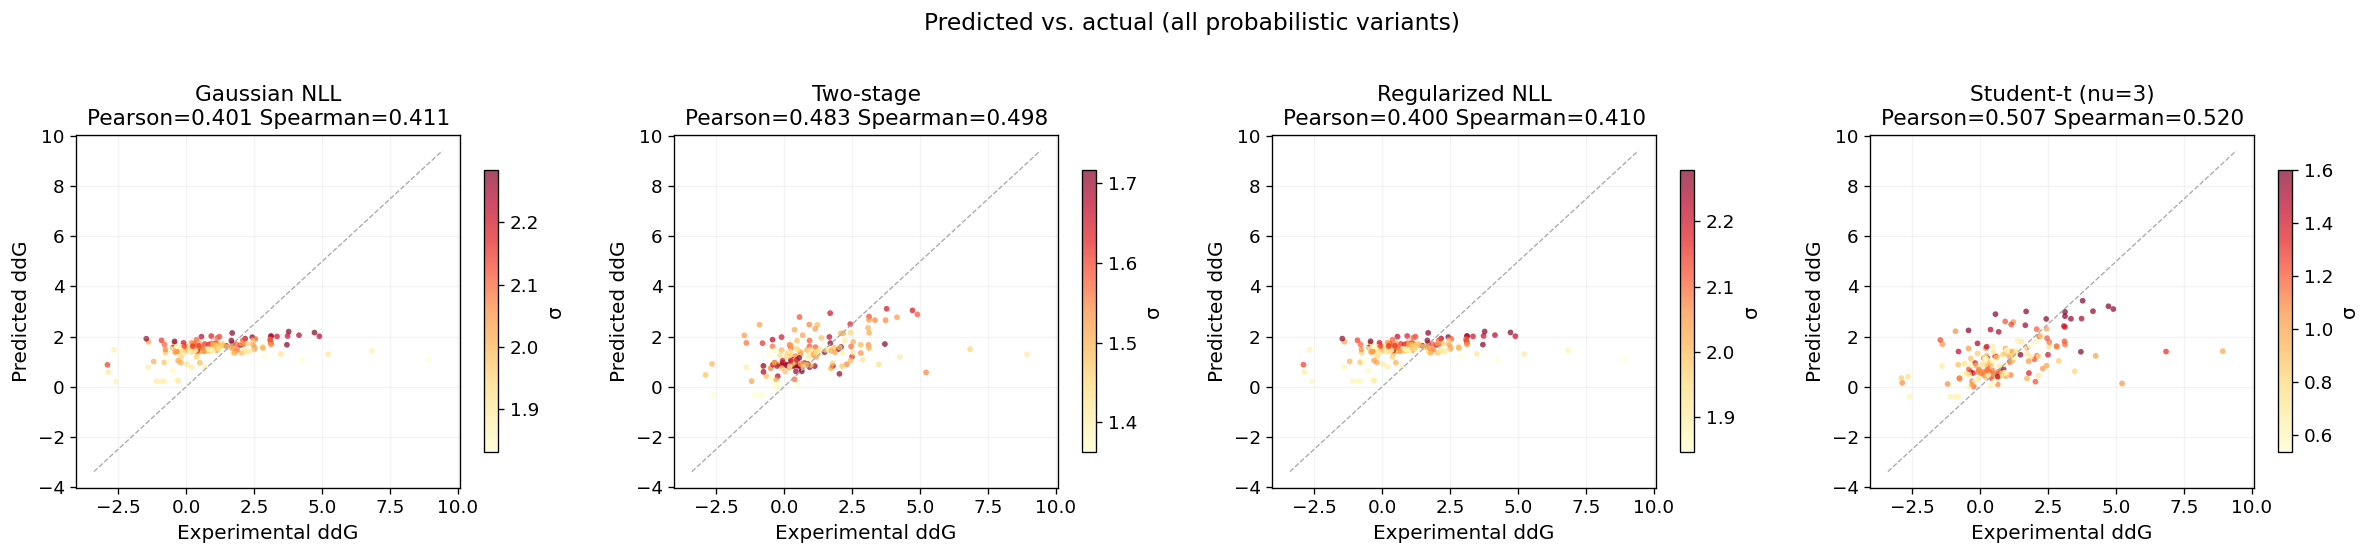

In [10]:
y_test = splits['test'][1].numpy()
prob_names = [n for n in EXPERIMENTS if is_probabilistic(EXPERIMENTS[n]['head'])]

fig, axes = plt.subplots(1, len(prob_names), figsize=(5*len(prob_names), 4.5))
if len(prob_names) == 1:
    axes = [axes]
for ax, name in zip(axes, prob_names):
    mu, sigma, y = prob_preds[name]
    sc = ax.scatter(y, mu, c=sigma, cmap='YlOrRd', s=12, alpha=0.7, edgecolors='none',
                    vmin=np.percentile(sigma, 5), vmax=np.percentile(sigma, 95))
    plt.colorbar(sc, ax=ax, label='\u03c3', shrink=0.8)
    lims = [min(y.min(), mu.min())-0.5, max(y.max(), mu.max())+0.5]
    ax.plot(lims, lims, color='#AAA', lw=0.8, ls='--')
    rp, _ = pearsonr(y, mu)
    rs, _ = spearmanr(y, mu)
    ax.set_title(f'{LABELS[name]}\nPearson={rp:.3f} Spearman={rs:.3f}')
    ax.set_xlabel('Experimental ddG')
    ax.set_ylabel('Predicted ddG')
fig.suptitle('Predicted vs. actual (all probabilistic variants)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 5. Reliability diagrams (all variants)

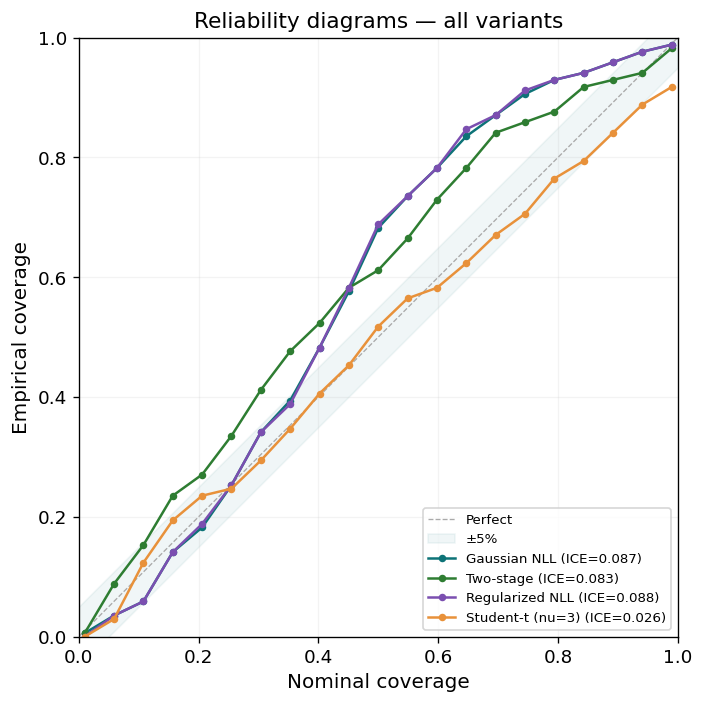

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0,1], [0,1], color='#AAA', lw=0.8, ls='--', label='Perfect')
x_d = np.linspace(0, 1, 100)
ax.fill_between(x_d, x_d-0.05, x_d+0.05, alpha=0.06, color='#0D7377', label='\u00b15%')

for name in prob_preds:
    mu, sigma, y = prob_preds[name]
    nominal, empirical = compute_coverage_curve(mu, sigma, y)
    ice = results[name].ice
    ax.plot(nominal, empirical, marker='o', ms=3.5, lw=1.5,
            color=COLORS[name], label=f'{LABELS[name]} (ICE={ice:.3f})')

ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability diagrams \u2014 all variants')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
plt.show()

---
## 6. Sigma distributions (comparison)

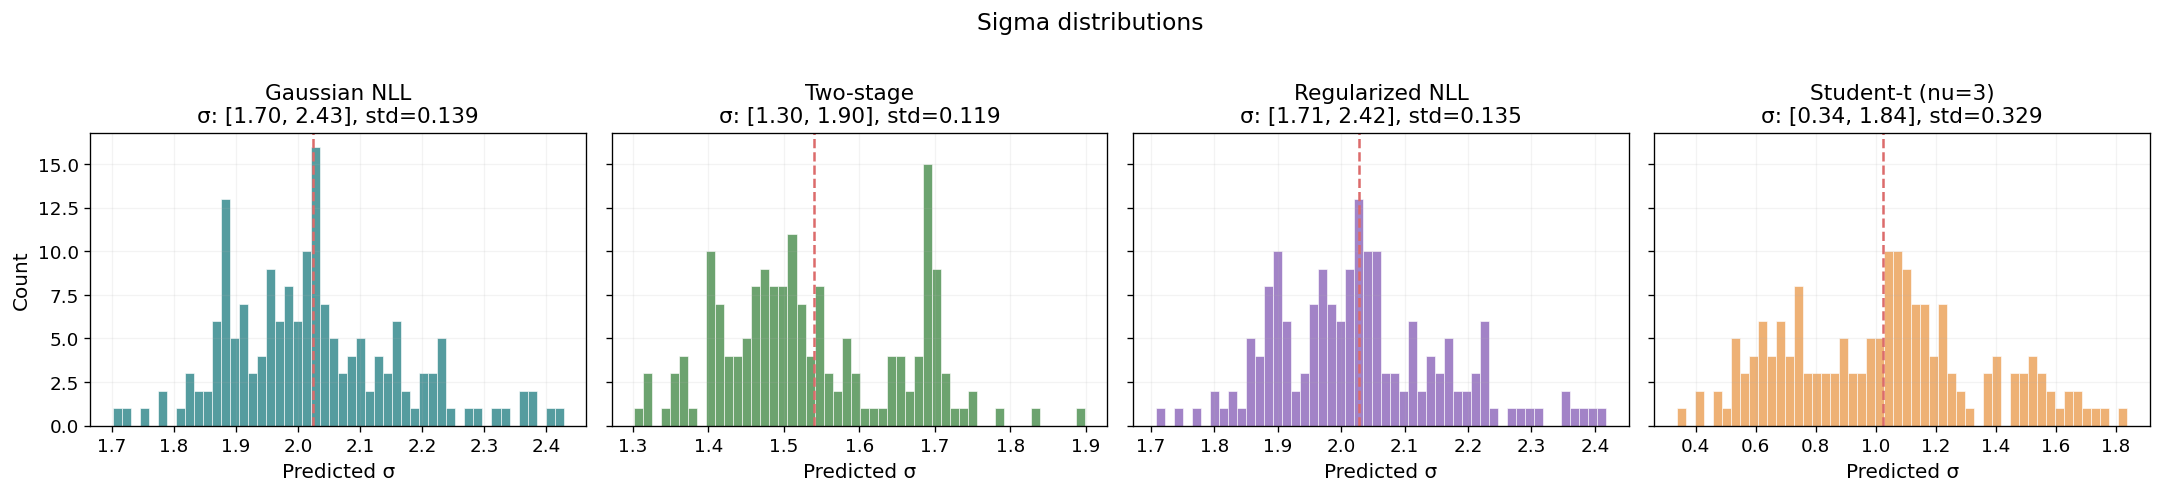

In [12]:
fig, axes = plt.subplots(1, len(prob_preds), figsize=(4.5*len(prob_preds), 4), sharey=True)
if len(prob_preds) == 1:
    axes = [axes]
for ax, name in zip(axes, prob_preds):
    mu, sigma, y = prob_preds[name]
    ax.hist(sigma, bins=50, color=COLORS[name], alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(sigma.mean(), color='#DC6B6B', ls='--', lw=1.5)
    ax.set_title(f'{LABELS[name]}\n\u03c3: [{sigma.min():.2f}, {sigma.max():.2f}], std={sigma.std():.3f}')
    ax.set_xlabel('Predicted \u03c3')
axes[0].set_ylabel('Count')
fig.suptitle('Sigma distributions', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 7. Sigma vs. error (does the model know what it doesn't know?)

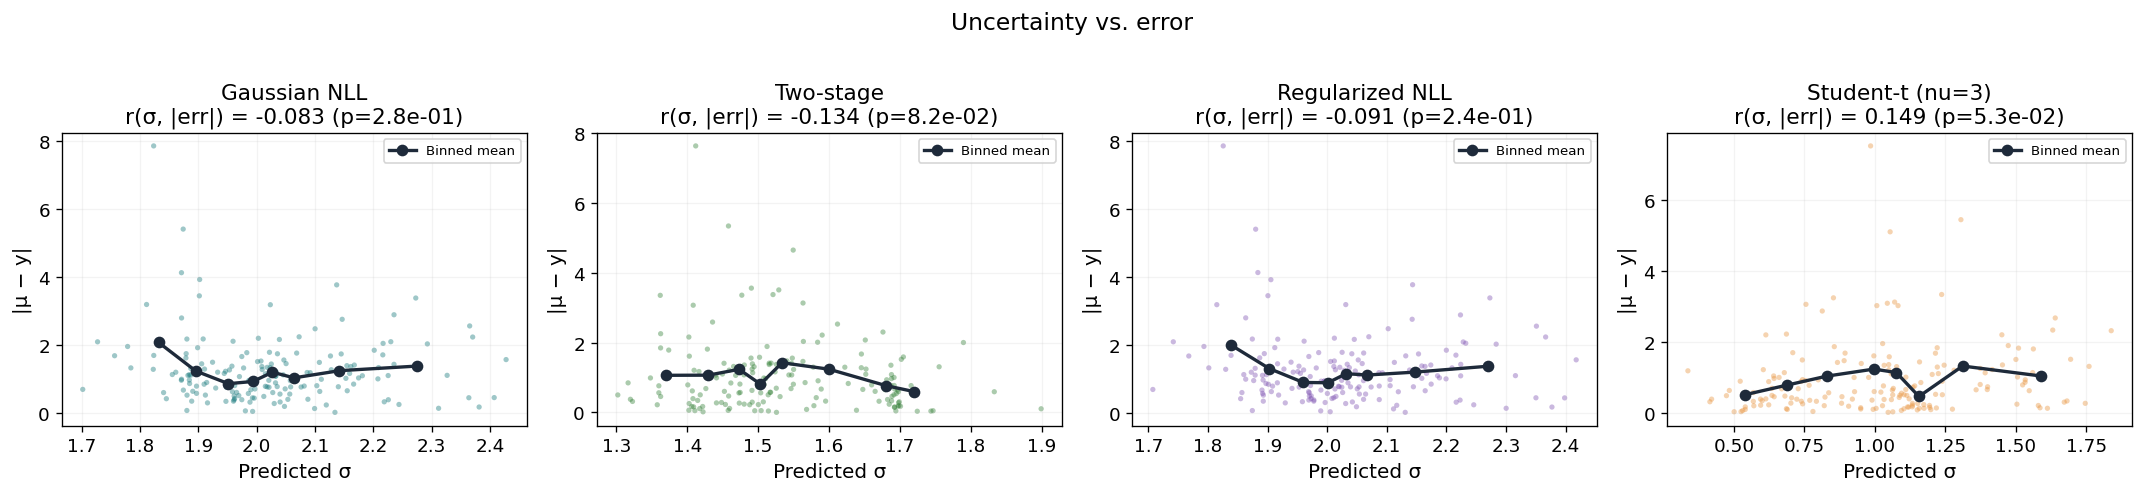

In [13]:
fig, axes = plt.subplots(1, len(prob_preds), figsize=(4.5*len(prob_preds), 4))
if len(prob_preds) == 1:
    axes = [axes]
for ax, name in zip(axes, prob_preds):
    mu, sigma, y = prob_preds[name]
    ae = np.abs(mu - y)
    ax.scatter(sigma, ae, c=COLORS[name], s=10, alpha=0.4, edgecolors='none')
    # Binned trend
    bins = np.percentile(sigma, np.linspace(0, 100, 9))
    bc, bm = [], []
    for i in range(len(bins)-1):
        m = (sigma >= bins[i]) & (sigma < bins[i+1])
        if m.sum() > 0:
            bc.append(sigma[m].mean()); bm.append(ae[m].mean())
    ax.plot(bc, bm, 'o-', color='#1E2A3A', ms=6, lw=2, label='Binned mean')
    r, p = pearsonr(sigma, ae)
    ax.set_title(f'{LABELS[name]}\nr(\u03c3, |err|) = {r:.3f} (p={p:.1e})')
    ax.set_xlabel('Predicted \u03c3')
    ax.set_ylabel('|\u03bc \u2212 y|')
    ax.legend(fontsize=8)
fig.suptitle('Uncertainty vs. error', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 8. Interpretability case studies

In [14]:
META_CSV = Path('cache/t2837_metadata.csv')
meta_df = pd.read_csv(META_CSV) if META_CSV.exists() else None

# Pick the best variant by ICE
best_name = min(prob_preds.keys(), key=lambda n: results[n].ice)
print(f'Best variant by ICE: {LABELS[best_name]} (ICE={results[best_name].ice:.4f})')

mu, sigma, y = prob_preds[best_name]

if meta_df is not None:
    test_meta = meta_df[meta_df['split'] == 'test'].reset_index(drop=True)
    if len(test_meta) == len(sigma):
        pred_df = test_meta.copy()
        pred_df['pred_mu'] = mu
        pred_df['pred_sigma'] = sigma
        pred_df['abs_error'] = np.abs(mu - y)
        pred_df['z_score'] = np.abs(mu - y) / np.maximum(sigma, 1e-8)
        AA3to1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLU':'E','GLN':'Q','GLY':'G',
                  'HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S',
                  'THR':'T','TRP':'W','TYR':'Y','VAL':'V'}
        pred_df['label'] = pred_df.apply(
            lambda r: f"{r['pdb_code']}:{r['chain_id']}{r['position']} {AA3to1.get(r['wtAA'],'?')}\u2192{AA3to1.get(r['mutAA'],'?')}", axis=1)
        print(f'Prediction dataframe: {len(pred_df)} mutations')
    else:
        pred_df = None
        print(f'Mismatch: meta={len(test_meta)} vs sigma={len(sigma)}')
else:
    pred_df = None
    print('No metadata CSV')

Best variant by ICE: Student-t (nu=3) (ICE=0.0258)
Prediction dataframe: 170 mutations


In [15]:
if pred_df is not None:
    cases = {
        'High confidence, correct': pred_df[
            (pred_df['pred_sigma'] < pred_df['pred_sigma'].quantile(0.2)) &
            (pred_df['abs_error'] < pred_df['abs_error'].quantile(0.2))],
        'High confidence, WRONG': pred_df[
            (pred_df['pred_sigma'] < pred_df['pred_sigma'].quantile(0.2)) &
            (pred_df['abs_error'] > pred_df['abs_error'].quantile(0.8))],
        'Low confidence, honest': pred_df[
            (pred_df['pred_sigma'] > pred_df['pred_sigma'].quantile(0.8)) &
            (pred_df['abs_error'] > pred_df['abs_error'].quantile(0.5))],
        'Low confidence, accurate': pred_df[
            (pred_df['pred_sigma'] > pred_df['pred_sigma'].quantile(0.8)) &
            (pred_df['abs_error'] < pred_df['abs_error'].quantile(0.2))],
    }
    for case_name, sub in cases.items():
        print(f'\n{"="*55}\n{case_name} ({len(sub)} found)\n{"="*55}')
        for _, r in sub.head(3).iterrows():
            loc = 'core' if r['rel_rsa']<20 else ('surface' if r['rel_rsa']>50 else 'mid')
            print(f'  {r["label"]}  |  actual={r["ddG"]:+.2f}  pred={r["pred_mu"]:+.2f}\u00b1{r["pred_sigma"]:.2f}  |  err={r["abs_error"]:.2f} ({r["z_score"]:.1f}\u03c3)  RSA={r["rel_rsa"]}% ({loc})')


High confidence, correct (8 found)
  2pr5:A90 V→I  |  actual=+0.70  pred=+0.82±0.69  |  err=0.12 (0.2σ)  RSA=0% (core)
  2ptl:A19 T→A  |  actual=+1.63  pred=+1.53±0.54  |  err=0.10 (0.2σ)  RSA=62% (surface)
  2ptl:A21 K→A  |  actual=+0.92  pred=+0.88±0.53  |  err=0.04 (0.1σ)  RSA=41% (mid)

High confidence, WRONG (2 found)
  2pr5:A120 V→I  |  actual=-1.40  pred=+0.82±0.69  |  err=2.22 (3.2σ)  RSA=0% (core)
  2pr5:A124 N→Y  |  actual=-2.60  pred=-0.40±0.61  |  err=2.20 (3.6σ)  RSA=3% (core)

Low confidence, honest (25 found)
  1a5e:A15 W→D  |  actual=-0.19  pred=+0.94±1.39  |  err=1.13 (0.8σ)  RSA=50% (mid)
  1g3p:A136 F→V  |  actual=+3.71  pred=+1.39±1.84  |  err=2.32 (1.3σ)  RSA=0% (core)
  1g3p:A137 Q→N  |  actual=+1.79  pred=+0.54±1.37  |  err=1.25 (0.9σ)  RSA=0% (core)

Low confidence, accurate (4 found)
  1g3p:A139 N→K  |  actual=+0.43  pred=+0.32±1.28  |  err=0.11 (0.1σ)  RSA=0% (core)
  1l6h:A48 Y→A  |  actual=+1.48  pred=+1.27±1.58  |  err=0.21 (0.1σ)  RSA=50% (mid)
  1xxn:A32

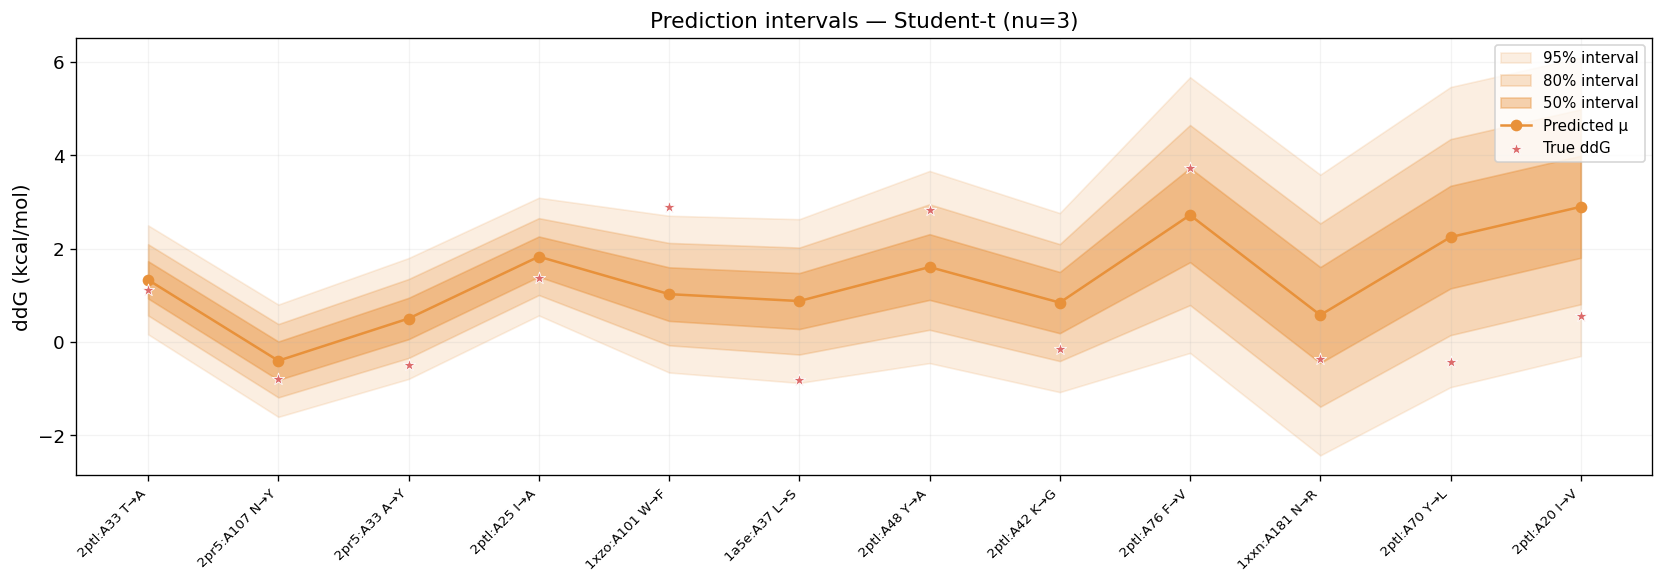

In [16]:
if pred_df is not None:
    # Prediction intervals for 12 selected mutations
    srt = pred_df.sort_values('pred_sigma')
    n = len(srt)
    showcase = pd.concat([
        srt.head(max(1,n//5)).sample(min(4,max(1,n//5)), random_state=42),
        srt.iloc[n//3:2*n//3].sample(min(4,max(1,n//3)), random_state=42),
        srt.tail(max(1,n//5)).sample(min(4,max(1,n//5)), random_state=42),
    ]).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 5))
    xp = np.arange(len(showcase))
    for lv, al, zm in [(0.95, 0.15, 1.96), (0.80, 0.25, 1.28), (0.50, 0.40, 0.67)]:
        lo = showcase['pred_mu'] - zm*showcase['pred_sigma']
        hi = showcase['pred_mu'] + zm*showcase['pred_sigma']
        ax.fill_between(xp, lo, hi, alpha=al, color=COLORS[best_name], label=f'{int(lv*100)}% interval')
    ax.plot(xp, showcase['pred_mu'], 'o-', color=COLORS[best_name], ms=6, lw=1.5, label='Predicted \u03bc', zorder=5)
    ax.scatter(xp, showcase['ddG'], color='#DC6B6B', s=60, marker='*', zorder=6, label='True ddG', edgecolors='white', linewidths=0.5)
    ax.set_xticks(xp)
    ax.set_xticklabels(showcase['label'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ddG (kcal/mol)')
    ax.set_title(f'Prediction intervals \u2014 {LABELS[best_name]}')
    ax.legend(fontsize=9, loc='upper right')
    fig.tight_layout()
    plt.show()

---
## 9. Summary

In [17]:
print('\nFinal comparison (v3)')
print('='*80)
print(cmp_df.to_string(index=False))
print()
best = min(prob_preds.keys(), key=lambda n: results[n].ice)
print(f'Best by ICE: {LABELS[best]}')
print(f'  ICE  = {results[best].ice:.4f}')
print(f'  RMSE = {results[best].rmse:.4f}')
print(f'  90%  = {results[best].coverage["0.90"]:.1%}')
rp, _ = pearsonr(prob_preds[best][2], prob_preds[best][0])
print(f'  Pearson r = {rp:.4f}')
print(f'  sigma std = {prob_preds[best][1].std():.4f} (spread of uncertainty)')


Final comparison (v3)
         Variant   RMSE    MAE    NLL    ICE 90% cov Pearson r sigma_mean sigma_std
    MSE baseline 1.6055 1.0925      —      —       —         —          —         —
    Gaussian NLL 1.5929 1.2536 1.9488 0.0865   95.9%    0.4006      2.024     0.139
       Two-stage 1.4455 1.0222 1.8181 0.0829   92.9%    0.4830      1.540     0.119
 Regularized NLL 1.5949 1.2562 1.9505 0.0876   95.9%    0.3999      2.028     0.135
Student-t (nu=3) 1.3978 0.9483 1.9010 0.0258   86.5%    0.5065      1.025     0.329

Best by ICE: Student-t (nu=3)
  ICE  = 0.0258
  RMSE = 1.3978
  90%  = 86.5%
  Pearson r = 0.5065
  sigma std = 0.3289 (spread of uncertainty)
